# Model Validation

Before interpreting network outcomes, the analysis confirms that public inputs and calibration targets yield a stable simulated rider population. The figures that follow examine cross-seed stability of aggregate attendance metrics, the distribution of baseline ride rates relative to the configured target, and the geographic distribution of scheduled studio capacity.


In [5]:
from pathlib import Path
import sys

# notebook runs from analysis and setting up project imports
sys.path.insert(0, str(Path.cwd().resolve().parent / "analysis"))
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
from notebook_paths import ensure_src_on_path

PROJECT_ROOT = ensure_src_on_path()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from soulcycle_network.calibration import (
    default_calibration_seeds,
    run_calibration_batch,
    summarize_calibration_batch,
)

# load calibration batch 
cal_path = RESULTS_DIR / "calibration.csv"
if cal_path.exists():
    calibration = pd.read_csv(cal_path)
else:
    calibration = run_calibration_batch(DATA_DIR, seeds=default_calibration_seeds(6400, 10))

summary = summarize_calibration_batch(calibration)
summary.loc[
    ["generated_mean_annual_ride_rate", "seat_occupancy_rate", "avg_attendance_per_week"]
].round(4)

,mean,std,min,max,cv
generated_mean_annual_ride_rate,11.5592,0.1396,11.3331,11.7767,0.0121
seat_occupancy_rate,0.6948,0.0082,0.6804,0.7090,0.0117
avg_attendance_per_week,2220.6269,26.0556,2174.4231,2265.8269,0.0117


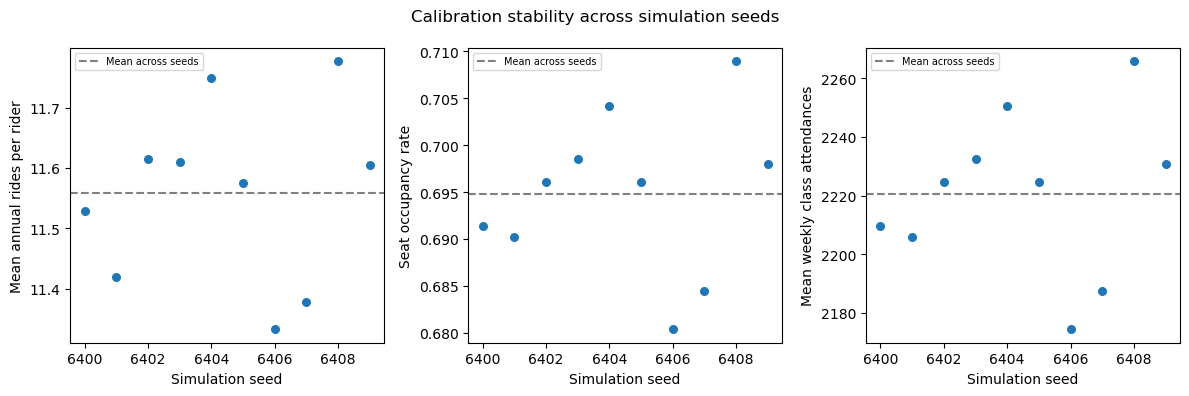

In [6]:
# scatter each calibration metric by seed
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
seeds = calibration["seed"]
metric_labels = [
    ("generated_mean_annual_ride_rate", "Mean annual rides per rider"),
    ("seat_occupancy_rate", "Seat occupancy rate"),
    ("avg_attendance_per_week", "Mean weekly class attendances"),
]
for ax, (col, ylab) in zip(axes, metric_labels):
    ax.scatter(seeds, calibration[col], s=30)
    ax.axhline(calibration[col].mean(), ls="--", c="gray", label="Mean across seeds")
    ax.set_xlabel("Simulation seed")
    ax.set_ylabel(ylab)
    ax.legend(fontsize=7, loc="best")
fig.suptitle("Calibration stability across simulation seeds")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_calibration_stability.png", dpi=150, bbox_inches="tight")
plt.show()

Calibration metrics vary little across the ten random seeds used for rider generation and booking; points remain close to the cross-seed mean rather than drifting. Stochastic draws therefore do not dominate population-level attendance in this setup, which supports comparing network results across seeds on a comparable footing. The quantities plotted are simulated aggregates, not observed studio attendance.


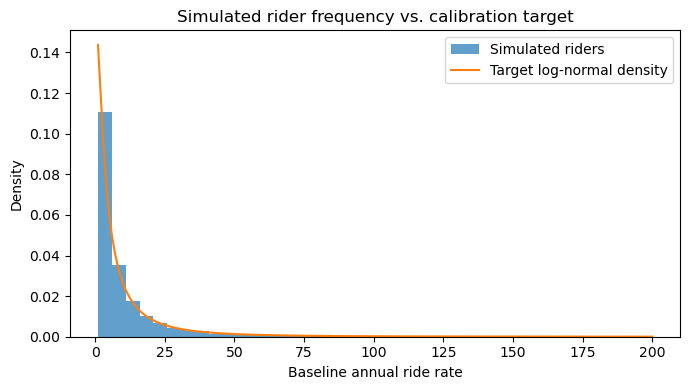

In [7]:
import numpy as np
from soulcycle_network.config import RIDER_FREQUENCY_PARAMETERS

params = RIDER_FREQUENCY_PARAMETERS
rates = pd.read_csv(RESULTS_DIR / "rider_nodes.csv")["baseline_annual_ride_rate"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rates, bins=40, density=True, alpha=0.7, label="Simulated riders")
# log-normal pdf from config file
grid = np.linspace(params["minimum"], params["maximum"], 200)
lognorm_pdf = np.exp(-((np.log(grid) - params["log_mean"]) ** 2) / (2 * params["log_sd"] ** 2))
lognorm_pdf = lognorm_pdf / (grid * params["log_sd"] * np.sqrt(2 * np.pi))
ax.plot(grid, lognorm_pdf, label="Target log-normal density")
ax.set_xlabel("Baseline annual ride rate")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Simulated rider frequency vs. calibration target")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_rider_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Simulated baseline annual ride rates align closely with the log-normal target specified in model configuration, including the intended skew toward moderate attendance and a longer upper tail among frequent riders. That distribution shapes exposure to co-attendance but does not, on its own, determine tie counts at week 52. The figure assesses input plausibility rather than empirical fit to rider behavior.


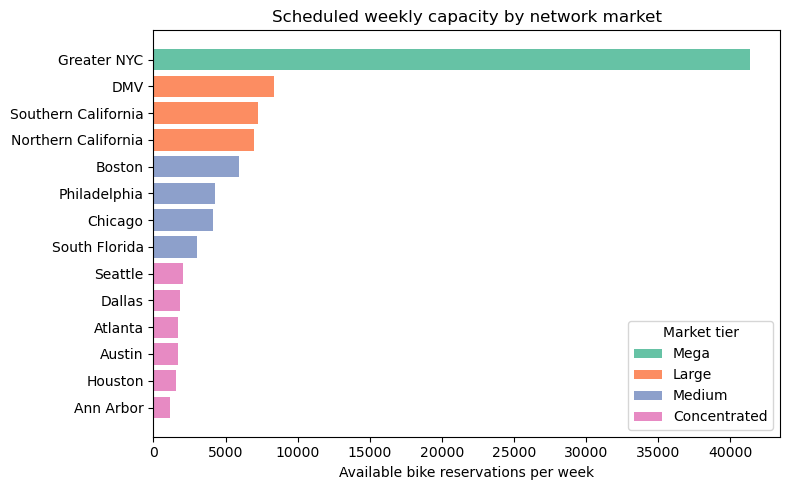

In [8]:
from matplotlib.patches import Patch

studios = pd.read_csv(DATA_DIR / "studios.csv")
# sum weekly slots by market and color bars by tier
cap = (studios.groupby("network_market", as_index=False).agg(weekly_capacity=("slots_per_wk", "sum"), market_tier=("market_tier", "first")).sort_values("weekly_capacity"))
tier_order = ["Mega", "Large", "Medium", "Concentrated"]
tier_colors = {t: plt.get_cmap("Set2")(i) for i, t in enumerate(tier_order)}
bar_colors = [tier_colors.get(t, "gray") for t in cap["market_tier"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cap["network_market"], cap["weekly_capacity"], color=bar_colors)
ax.set_xlabel("Available bike reservations per week")
ax.set_title("Scheduled weekly capacity by network market")
handles = [Patch(facecolor=tier_colors[t], label=t) for t in tier_order if t in set(cap["market_tier"])]
ax.legend(handles=handles, title="Market tier", loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_weekly_capacity_by_market.png", dpi=150, bbox_inches="tight")
plt.show()

Scheduled weekly bike reservations are concentrated in Greater NYC and decline through the Mega, Large, Medium, and Concentrated market tiers. Capacity reflects the number of reservable seats implied by the studio schedule (an upper bound on potential attendance volume, not foot traffic or a count of unique riders). Geographic unevenness in capacity nevertheless conditions tie formation by expanding or constraining the studios, instructors, and class slots available for repeated encounters.
